## Product-type 1 <통계>
- 데이터 로드
- 기술 통계량 확인
    - 공정/환경변수
    - 전체 샘플 수 대비 불량 제품의 비율
- 스피어만 상관계수 히트맵
    - 공정/환경변수
- histograms, Box-Plot
    - 공정/환경변수
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- Welch's T-test
    - 공정/환경변수
- Mann-Whitney U 검정
    - 공정/환경변수

In [67]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### **1. 데이터 로드**

In [68]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_1 = pd.read_csv('data/for_process_data_product-1.csv')
df_sensor_1 = pd.read_csv('data/for_sensor_data_product-1.csv')
df_defects_1 = pd.read_csv('data/for_defects_data_product-1.csv')
df_original_1 = pd.read_csv('data/for_entire_data_product-1.csv')

In [69]:
# 2. 데이터 크기 확인
print(f"제품 1의 전체 데이터 크기: {df_original_1.shape}")

print(f"제품 1의 process 관련 데이터 크기: {df_process_1.shape}")
print(f"제품 1의 sensor 관련 데이터 크기: {df_sensor_1.shape}")
print(f"제품 1의 defects 관련 데이터 크기: {df_defects_1.shape}")

제품 1의 전체 데이터 크기: (4207, 24)
제품 1의 process 관련 데이터 크기: (4207, 15)
제품 1의 sensor 관련 데이터 크기: (4207, 6)
제품 1의 defects 관련 데이터 크기: (4207, 3)


In [70]:
# 3-1. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 처리할 예정
defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 3-2. 결함과 관련된 데이터프레임
df_defects_1['is_defect'] = df_defects_1[defect_cols].max(axis=1)
# 불량유형을 is_defect로 통합하고, 개별 불량 유형 컬럼은 삭제
df_defects_1_1 = df_defects_1.drop(columns=defect_cols)

display(df_defects_1_1.head(5))

,is_defect
0,0
1,0
2,0
3,1
4,0


In [71]:
# 3-4. 전체 데이터프레임
df_original_1['is_defect'] = df_original_1[defect_cols].max(axis=1)
# 불량유형을 is_defect로 통합하고, 개별 불량 유형 컬럼은 삭제
df_original_1_1 = df_original_1.drop(columns=defect_cols)

display(df_original_1_1.head(5))

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,1_1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0
1,1002_2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
2,2003_3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
3,3004_4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,1
4,4005_5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0


In [72]:
# 3-6. 머신러닝을 위한 데이터 저장 (주석을 해제하면 저장 가능)
# df_original_1_1.to_csv("../data/ML_modeling_data_product-1.csv", index=False)

---
---
### **2. 기술통계**

#### 2.1 기술통계량 및 불량률 확인

In [105]:
# 1. 기술통계
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기술 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
        # 표준편차 기준 내림차순 정렬 후 상위 4개만 출력
    stats_df = stats_df.sort_values('표준편차', ascending=False)
    display(stats_df.head(4))

In [106]:
create_statistics_summary(df_process_1, "공정(process)")
create_statistics_summary(df_sensor_1, "환경(sensor)")


공정(process) 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
casting_pressure,4207.0,1063.822201,42.899758,516.0,1039.0,1052.0,1055.0,1164.0,-0.593293
cylinder_pressure,4207.0,219.793202,8.888864,107.0,215.0,217.0,218.0,241.0,-0.587423
cycle_time,4207.0,21.432113,6.411477,20.2,20.7,20.9,21.2,218.6,24.49784
clamping_force,4207.0,255.877110,2.465235,238.0,254.0,257.0,258.0,263.0,-0.895664



환경(sensor) 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,4207.0,700.388614,14.365077,671.0,689.15,701.2,710.65,730.0,0.037698
factory_humidity,4207.0,60.528548,7.051350,45.5,57.40,62.5,65.60,70.7,-0.788468
factory_temp,4207.0,33.015997,1.748600,30.6,32.00,32.2,34.50,37.0,0.935854
air_pressure,4207.0,6.100903,0.623627,4.6,5.80,6.2,6.60,7.1,-0.588247


In [75]:
# 2. 전체 샘플 수 & 불량률
total    = len(df_original_1_1)
n_defect = df_original_1_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"=== 전체 데이터 대비 불량률 ===")
print(f"\n전체 샘플: {total:,}개")
print(f"불량인 제품: {int(n_defect):,}개")
print(f"정상인 제품: {int(n_normal):,}개")
print(f"불량률: {rate:.2f}%")
print('='*28)

=== 전체 데이터 대비 불량률 ===

전체 샘플: 4,207개
불량인 제품: 739개
정상인 제품: 3,468개
불량률: 17.57%


#### 2.2 기술통계 해석
**(1) 불량인 제품의 개수와 비율 확인**
- Product type 1 데이터는 총 4,207개의 관측치로 구성되어 있으며, 정상인 제품이 3,468개, 불량인 제품이 739개이므로 불량률이 약 17.57%이다.
> 정상 비율이 더 높지만 불량 비중도 무시하기 어려운 수준이므로, 이후 정상/불량 비교 통계에서도 두 집단의 차이를 함께 살펴볼 필요가 있다.


**(2) 공정관련 변수 (df_process) 데이터 기술통계량 해석**
- 공정 변수 대부분은 평균과 중앙값의 차이가 크지 않고, 값이 비교적 좁은 범위에 분포하여 전반적으로는 안정적인 편이다. 하지만, `cycle_time`은 최대값이 매우 크게 나타나고, `high_velocity`, `rapid_rise_time` 등은 일부 0값의 영향이 확인되어 분포가 치우친 변수들이 존재한다.
> 따라서 제품유형 1의 공정 변수는 모든 변수가 균일한 정규형 분포를 따른다기보다, 일부 변수는 안정적이고 일부 변수는 치우침과 극단값의 영향을 함께 가지는 구조로 해석하는 것이 적절하다.

**(3) 환경관련 변수(df_sensor) 데이터 기술통계량 해석**
- 환경관련 변수는 전체적으로 공정 변수보다 비교적 안정적인 편이다. 다만 `factory_temp`, `factory_humidity` 등은 분포의 치우침이 상대적으로 크게 나타난다.\
> 따라서 환경관련 변수도 단순히 안정적이라고 해석하는 것보다, 일부 변수에서 비대칭성이 존재한다고 해석하는 것이 적절하다.

**(4) 기술통계량 해석 종합**
- 제품유형 1 데이터는 정상 제품이 더 많지만 불량 비율도 약 17% 수준으로 나타나, 품질 비교 분석의 의미가 충분하다.
> 기술통계량만 보았을 때 공정/환경관련 변수 모두 일부 변수에서 비대칭성과 극단값의 영향이 확인되므로,
이후 정규성 검정, 등분산성 검정등으로 정상과 불량 간 차이를 추가로 확인하는 흐름이 타당하다.

---
---
### **3. EDA 시행**

#### 3.1 스피어만 상관계수 히트맵

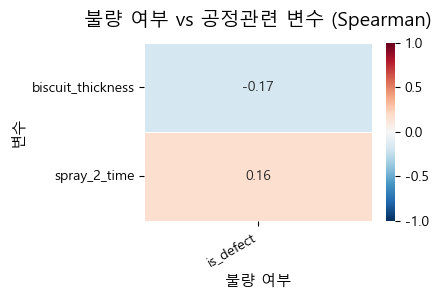

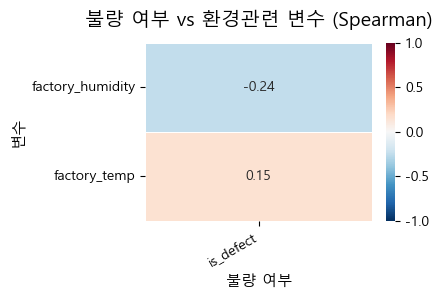

In [108]:
# 1. 변수 정의
DEFECT_COLS = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 2. 스피어만 상관계수 히트맵 시각화 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    # 절댓값 기준 상위 2개만 선택
    corr_target = corr_target.reindex(corr_target['is_defect'].abs().sort_values(ascending=False).head(2).index)

    fig, ax = plt.subplots(figsize=(4.5, len(corr_target) * 0.8 + 1.5))

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )


    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 여부', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 3. 함수 출력
plot_corr_heatmap(df_original_1_1, DEFECT_COLS, PROCESS_COLS, '불량 여부 vs 공정관련 변수 (Spearman)')
plot_corr_heatmap(df_original_1_1, DEFECT_COLS, SENSOR_COLS, '불량 여부 vs 환경관련 변수 (Spearman)')

#### 3.3 히스토그램 & 박스플롯

##### 3.3.1 히스토그램

In [77]:
# 1. histogram 시각화 함수 정의
import math

def plot_histograms(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    # 변수 1개당 1행, 정상/불량 2열
    n_rows = len(cols)

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 3.5))
    
    # 변수 1개일 때도 2차원 형태 유지
    if n_rows == 1:
        axes = axes.reshape(1, 2)

    for i, col in enumerate(cols):
        # 정상
        sns.histplot(
            data=df_a[df_a["is_defect"] == "정상"],
            x=col,
            bins=30,
            stat="density",
            kde=True,
            color="#4E4CB0",
            alpha=0.4,
            ax=axes[i, 0]
        )
        axes[i, 0].set_title(f"{col} - 정상", fontsize=11, fontweight="bold")
        axes[i, 0].set_xlabel("")
        axes[i, 0].set_ylabel("Density")

        # 불량
        sns.histplot(
            data=df_a[df_a["is_defect"] == "불량"],
            x=col,
            bins=30,
            stat="density",
            kde=True,
            color="#DD5252",
            alpha=0.4,
            ax=axes[i, 1]
        )
        axes[i, 1].set_title(f"{col} - 불량", fontsize=11, fontweight="bold")
        axes[i, 1].set_xlabel("")
        axes[i, 1].set_ylabel("Density")

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

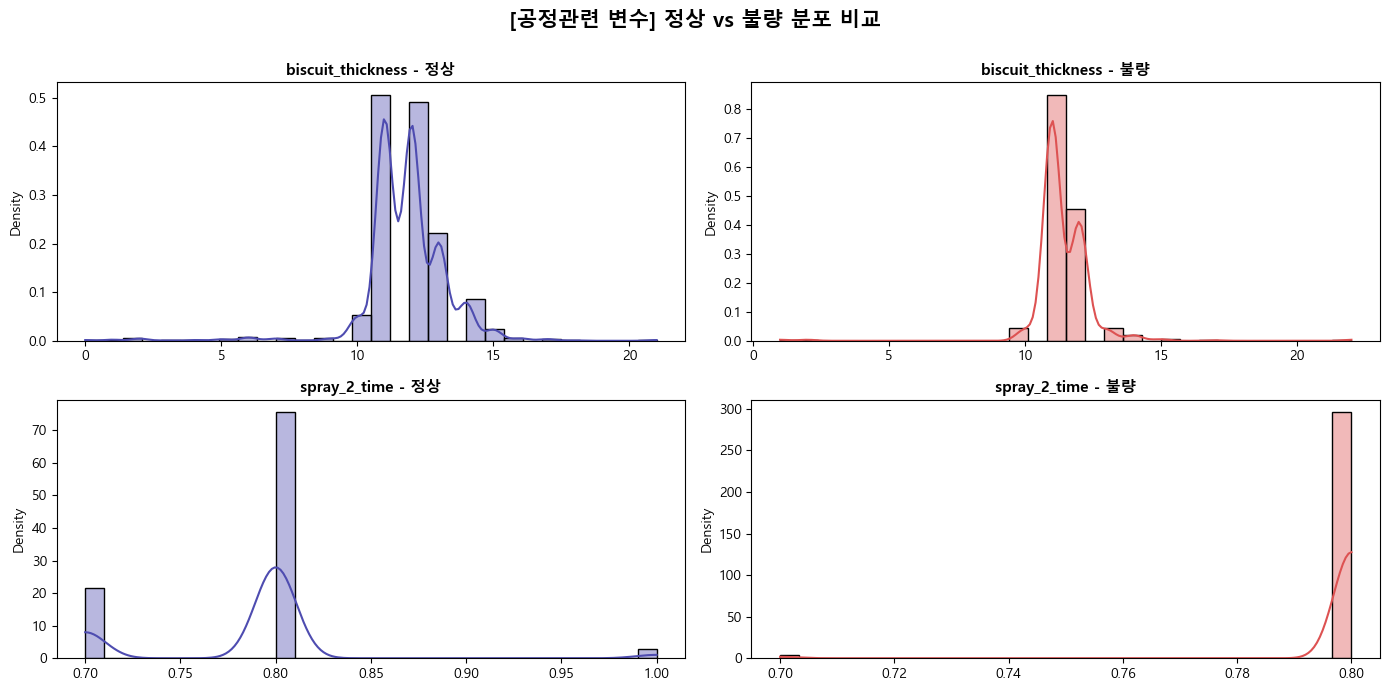

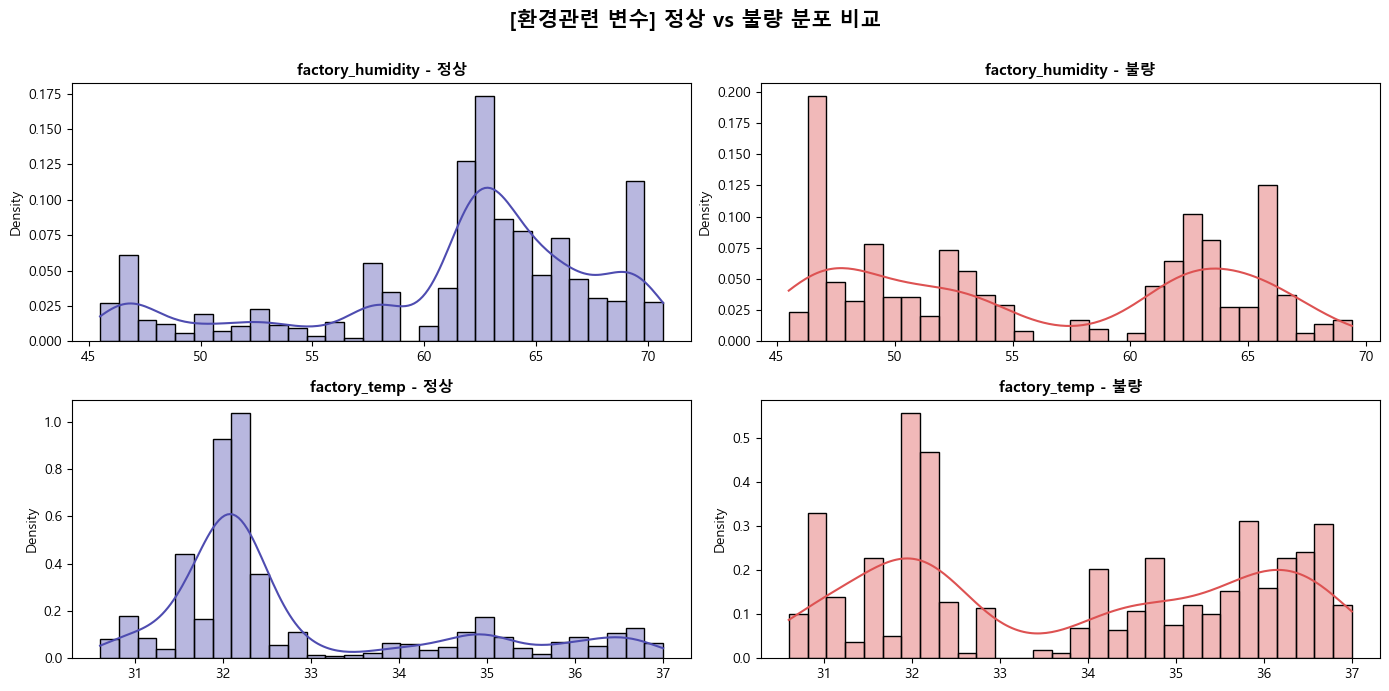

In [78]:
histogram_of_process_1 = plot_histograms(
    df_original_1_1,
    ["biscuit_thickness", "spray_2_time"],
    "공정관련 변수"
)

histogram_of_sensor_1 = plot_histograms(
    df_original_1_1,
    ["factory_humidity", "factory_temp"],
    "환경관련 변수"
)

##### 3.3.3 박스플롯

In [79]:
# 1. box plot 시각화 함수 정의
def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#534CB0", "불량": "#DD5252"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 비어있는 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

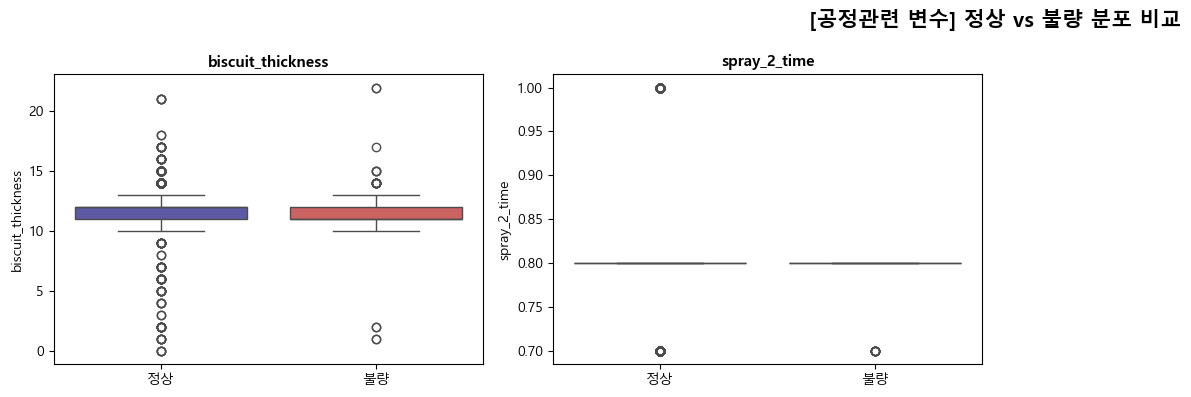

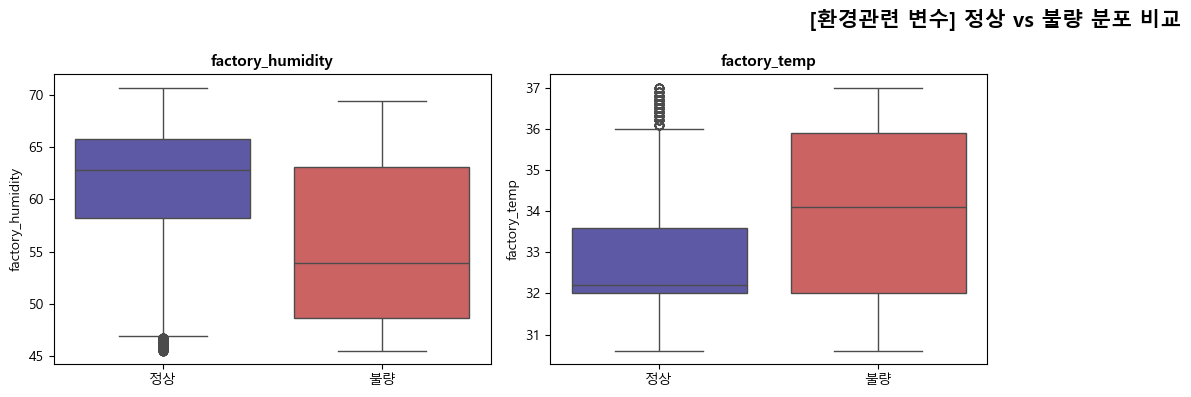

In [80]:
boxplot_of_process_1 = plot_boxplots(
    df_original_1_1,
    ["biscuit_thickness", "spray_2_time"],
    "공정관련 변수"
)

boxplot_of_sensor_1 = plot_boxplots(
    df_original_1_1,
    ["factory_humidity", "factory_temp"],
    "환경관련 변수"
)

---
---
### **4. 정규성 검정**

#### 4.1 Shapiro-Wilk 검정

In [81]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary_by_group(df, df_name, group_col="is_defect", exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정: 정상/불량 그룹별"""
    
    print(f"\n{'='*80}")
    print(f"{df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk, 그룹별)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    result_dict = {}

    # 그룹별 반복
    for group_value, group_name in [(0, "정상"), (1, "불량")]:
        print(f"\n[그룹: {group_name}]")
        
        group_df = df_copied[df_copied[group_col] == group_value].copy()
        
        # 숫자형 컬럼만 선택
        group_df = group_df.select_dtypes(include="number")
        
        # group_col 제외
        group_df = group_df.drop(columns=[group_col], errors="ignore")

        # 출력값 저장
        result_list = []

        for col in group_df.columns:
            series = group_df[col].dropna()

            # 정규성 확인: Shapiro-Wilk
            stat, p_value = stats.shapiro(series)

            # H0: 정규성을 만족한다.
            # H1: 정규성을 불만족한다.
            if p_value >= alpha:
                result = "정규성 만족"
            else:
                result = "정규성 불만족"

            # 출력값
            result_list.append([
                col, 
                stat, 
                p_value,
                result
            ])

        # 출력화면
        shapiro_df = pd.DataFrame(
            result_list,
            columns=[
                "변수명", 
                "Shapiro 검정통계량", 
                "p-value", 
                "판정"]
        ).set_index("변수명")

        display(shapiro_df)
        result_dict[group_name] = shapiro_df

    return result_dict

In [82]:
# 2. 함수 실행
shapiro_process_1 = create_shapiro_summary_by_group(
    df_original_1_1[["is_defect"] + PROCESS_COLS],
    "공정 변수"
)


공정 변수 관련 데이터 정규성 검정 (Shapiro-Wilk, 그룹별)


[그룹: 정상]


,Shapiro 검정통계량,p-value,판정
변수명,,,
velocity_1,0.567309,1.100492e-68,정규성 불만족
velocity_2,0.424497,1.956664e-74,정규성 불만족
velocity_3,0.739290,4.690174e-59,정규성 불만족
high_velocity,0.231248,1.630815e-80,정규성 불만족
cylinder_pressure,0.615518,2.257681e-66,정규성 불만족
rapid_rise_time,0.599100,3.466234e-67,정규성 불만족
biscuit_thickness,0.752756,4.325422e-58,정규성 불만족
clamping_force,0.928968,9.327624e-38,정규성 불만족
cycle_time,0.055923,5.633035e-85,정규성 불만족



[그룹: 불량]


,Shapiro 검정통계량,p-value,판정
변수명,,,
velocity_1,0.913091,3.814448e-20,정규성 불만족
velocity_2,0.871059,3.283872e-24,정규성 불만족
velocity_3,0.969604,2.889050e-11,정규성 불만족
high_velocity,0.983244,1.761784e-07,정규성 불만족
cylinder_pressure,0.523282,1.502183e-40,정규성 불만족
rapid_rise_time,0.523941,1.571554e-40,정규성 불만족
biscuit_thickness,0.512287,7.122781e-41,정규성 불만족
clamping_force,0.842523,2.011397e-26,정규성 불만족
cycle_time,0.035068,3.415249e-51,정규성 불만족


In [83]:
shapiro_sensor_1 = create_shapiro_summary_by_group(
    df_original_1_1[["is_defect"] + SENSOR_COLS],
    "환경 변수"
)


환경 변수 관련 데이터 정규성 검정 (Shapiro-Wilk, 그룹별)


[그룹: 정상]


,Shapiro 검정통계량,p-value,판정
변수명,,,
melting_furnace_temp,0.981626,8.205625e-21,정규성 불만족
air_pressure,0.944127,2.315975e-34,정규성 불만족
coolant_temp,0.942412,8.840361e-35,정규성 불만족
coolant_pressure,0.865755,1.436935e-47,정규성 불만족
factory_temp,0.803452,5.206129e-54,정규성 불만족
factory_humidity,0.878984,6.870359e-46,정규성 불만족



[그룹: 불량]


,Shapiro 검정통계량,p-value,판정
변수명,,,
melting_furnace_temp,0.986612,2.755930e-06,정규성 불만족
air_pressure,0.965590,3.624826e-12,정규성 불만족
coolant_temp,0.951850,8.318018e-15,정규성 불만족
coolant_pressure,0.950665,5.223062e-15,정규성 불만족
factory_temp,0.888710,1.202762e-22,정규성 불만족
factory_humidity,0.878550,1.441830e-23,정규성 불만족


#### 4.2 Q-Q Plot

In [84]:
# 1. Q-Q plot
def plot_qq_table(df, cols=None, title=None, exclude_cols=None, group_col="is_defect", group_value=None):
    """Q-Q plot 그래프"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 그룹 필터링
    if group_value is not None:
        df_copied = df_copied[df_copied[group_col] == group_value]

    # cols 지정 시 그 컬럼만 사용
    if cols is not None:
        cols = [col for col in cols if col in df_copied.columns]
    else:
        cols = df_copied.select_dtypes(include='number').columns.tolist()
        if group_col in cols:
            cols.remove(group_col)
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

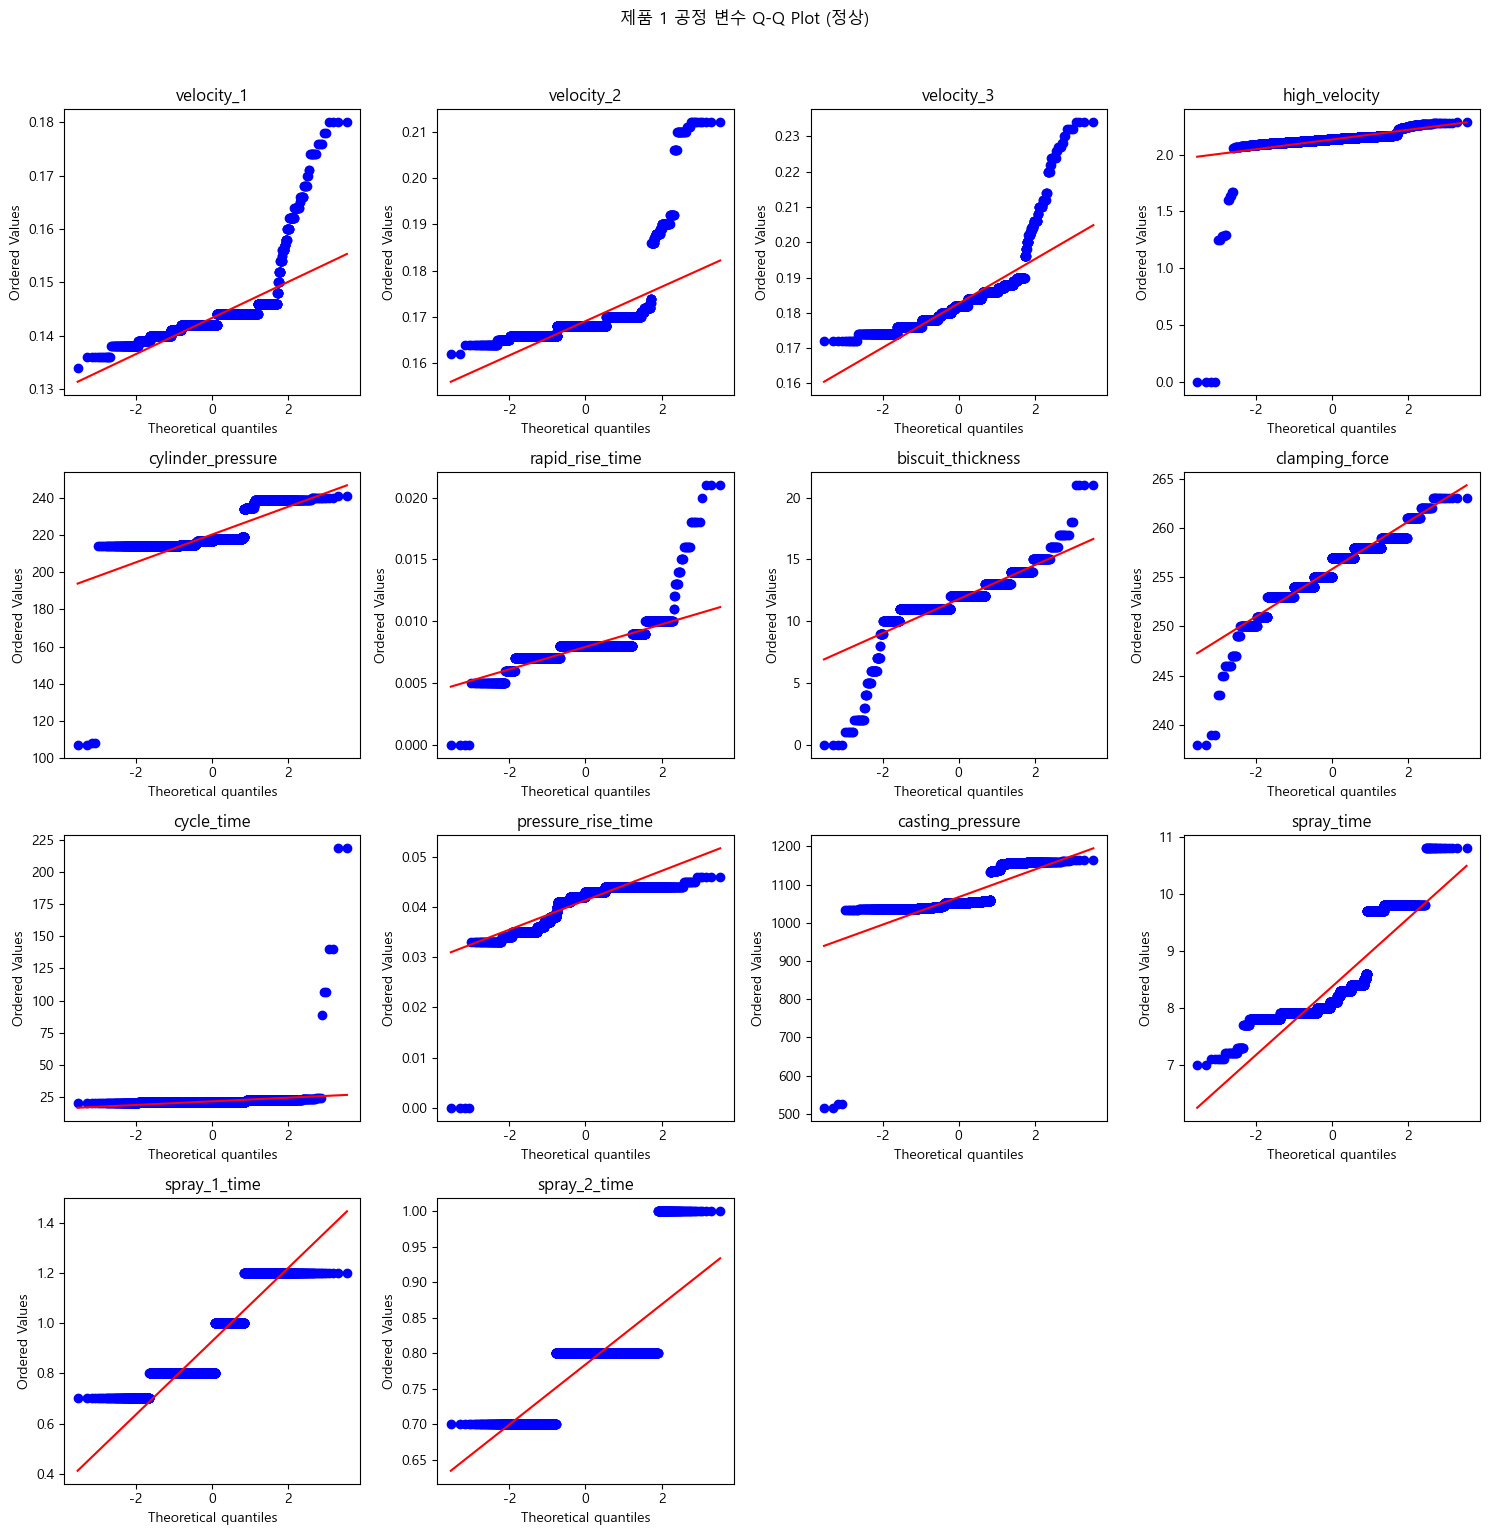

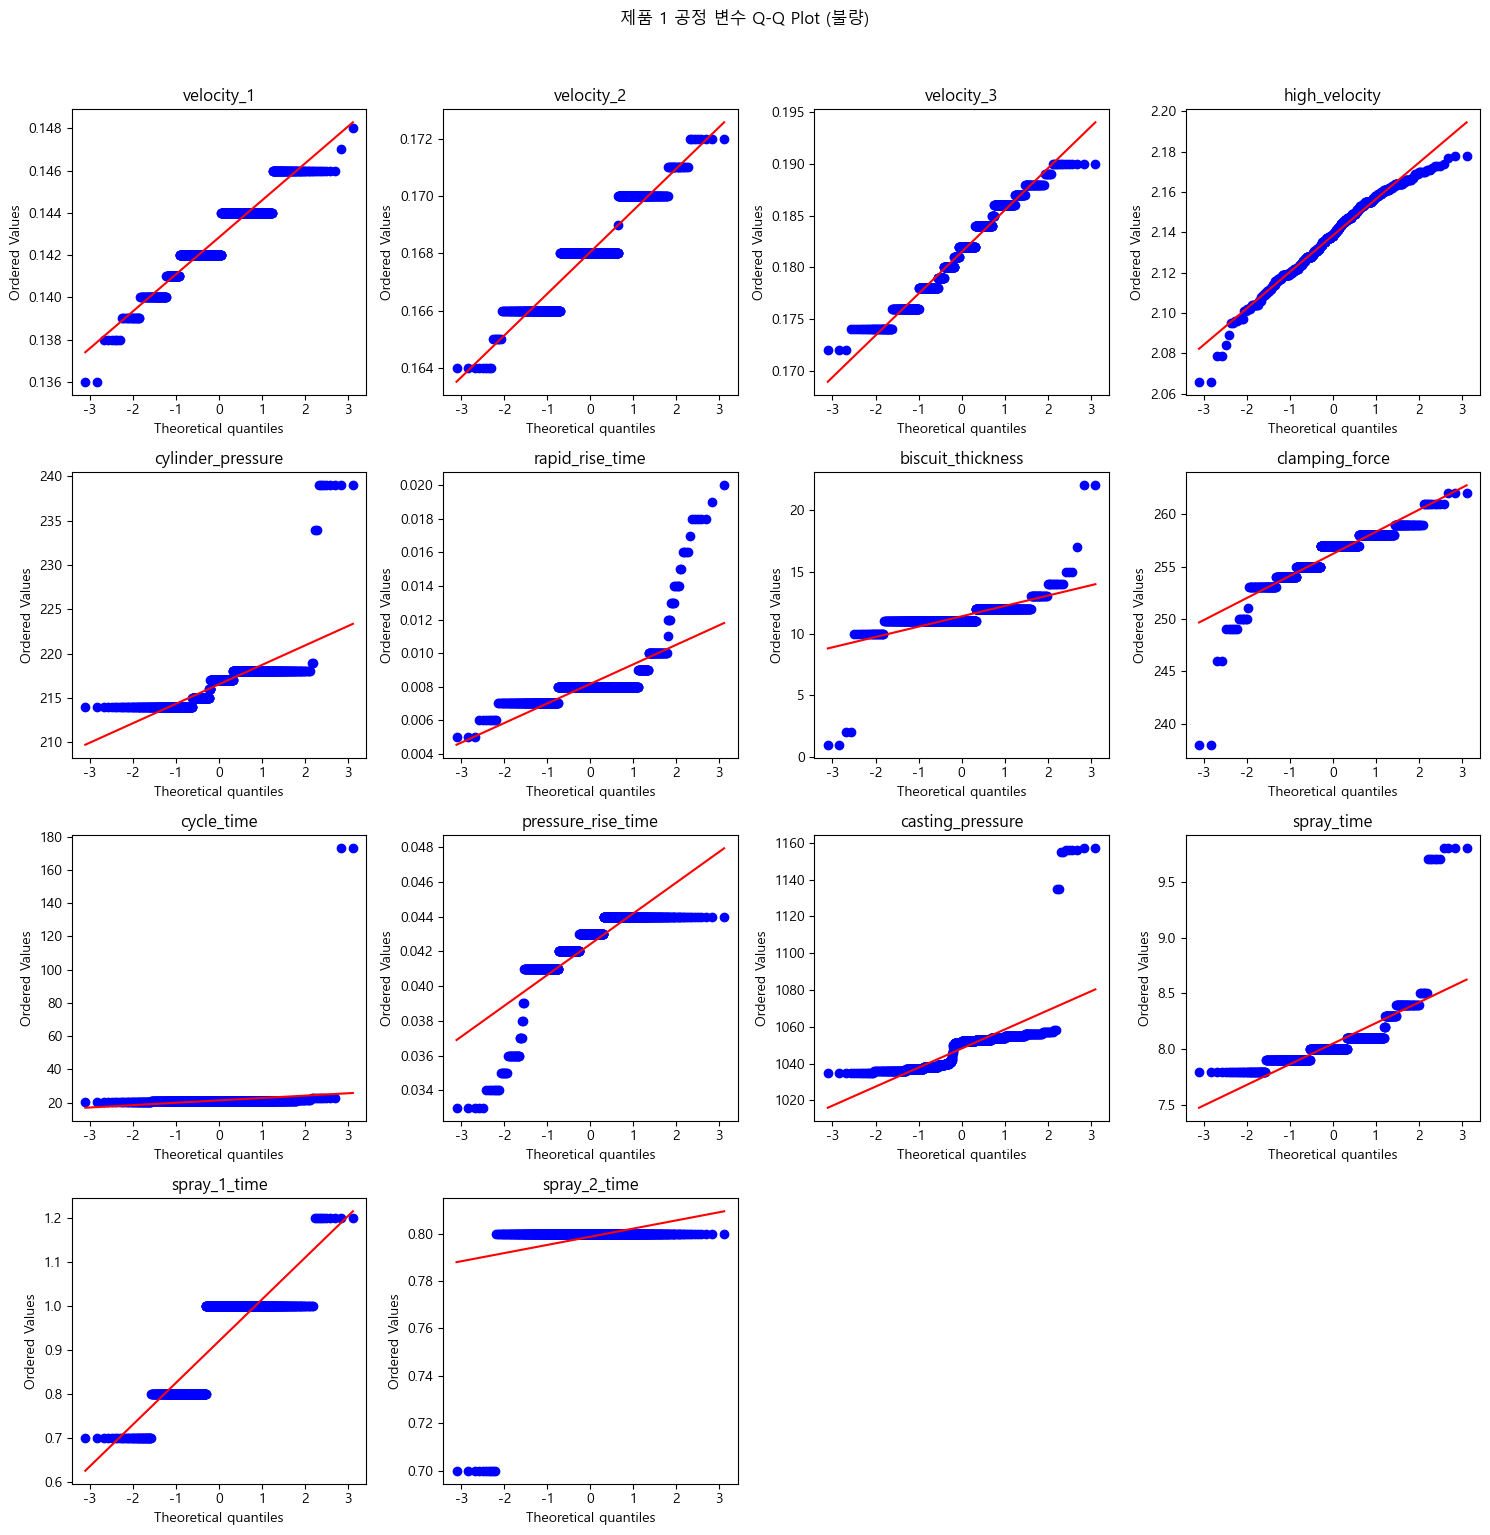

In [85]:
# 2. 함수 실행
# 제품 1 - 공정 변수 - 정상
plot_qq_table(
    df_original_1_1,
    cols=PROCESS_COLS,
    title="제품 1 공정 변수 Q-Q Plot (정상)",
    group_value=0
)

# 제품 1 - 공정 변수 - 불량
plot_qq_table(
    df_original_1_1,
    cols=PROCESS_COLS,
    title="제품 1 공정 변수 Q-Q Plot (불량)",
    group_value=1
)

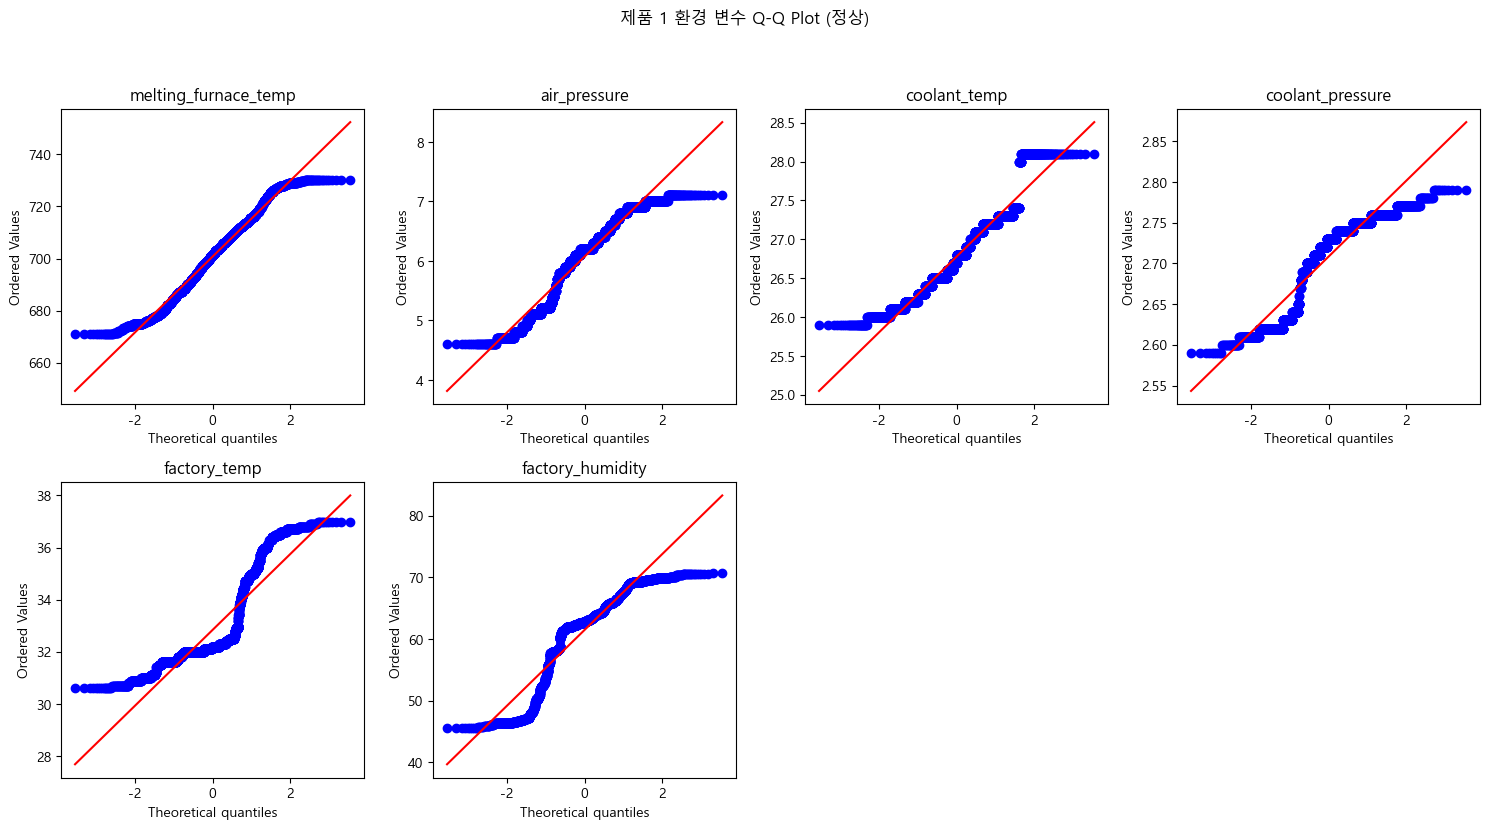

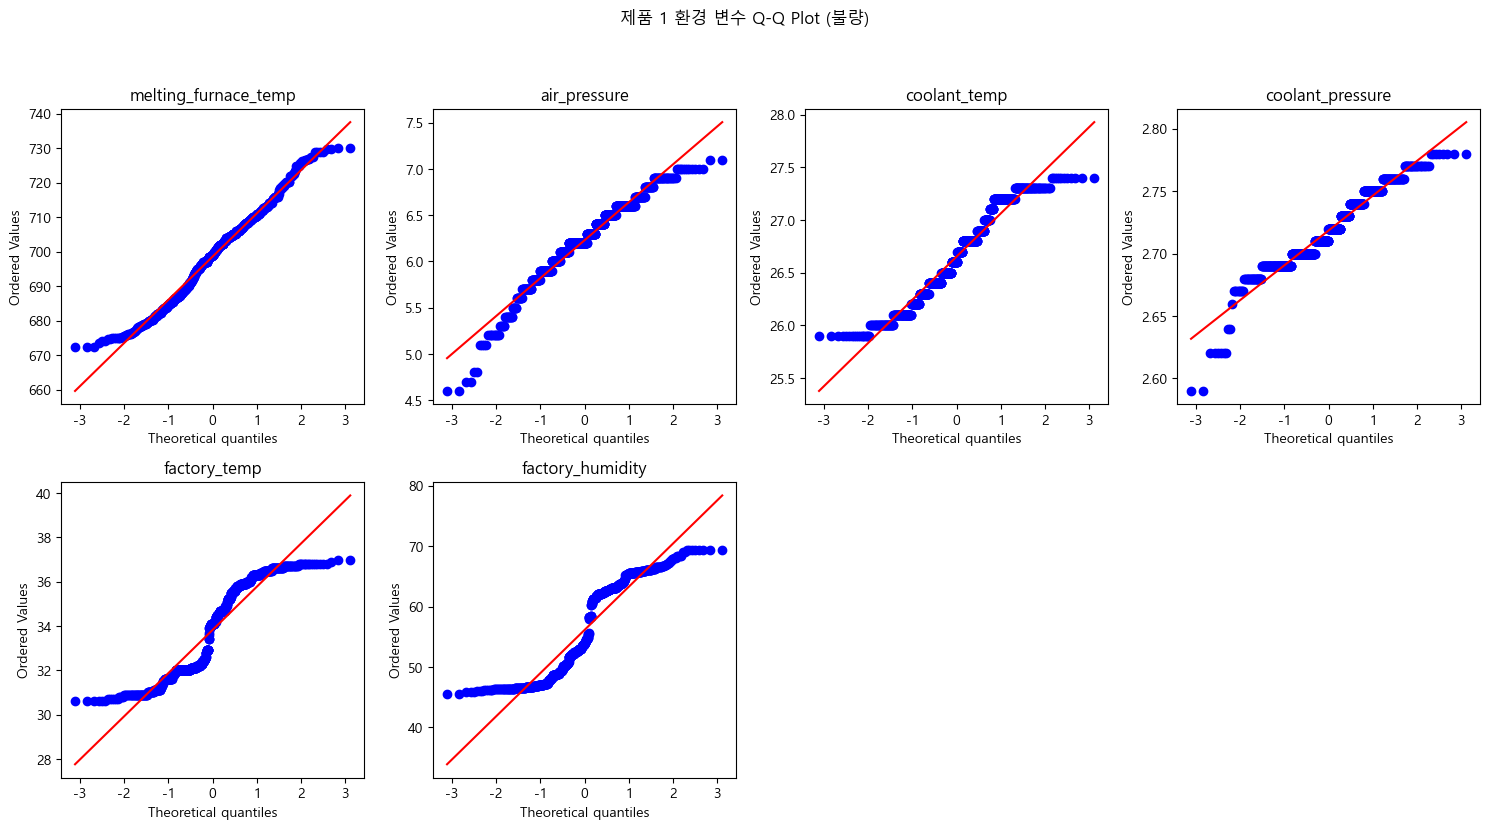

In [86]:
# 제품 1 - 환경 변수 - 정상
plot_qq_table(
    df_original_1_1,
    cols=SENSOR_COLS,
    title="제품 1 환경 변수 Q-Q Plot (정상)",
    group_value=0
)

# 제품 1 - 환경 변수 - 불량
plot_qq_table(
    df_original_1_1,
    cols=SENSOR_COLS,
    title="제품 1 환경 변수 Q-Q Plot (불량)",
    group_value=1
)

#### 4.4 Levene 검증

In [87]:
from scipy.stats import levene

# 1. 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력할 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [88]:
# 2. 함수 실행
process_levene_surface = create_levene_summary(
    df_process_1,
    df_defects_1_1,
    "is_defect",
    "df_process_1",
    exclude_cols=['shot_key']
)


df_process_1 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,21.089683,4.510936e-06,등분산 가정 불가
velocity_2,27.120408,2.003106e-07,등분산 가정 불가
velocity_3,26.808306,2.351704e-07,등분산 가정 불가
high_velocity,11.845690,5.835823e-04,등분산 가정 불가
cylinder_pressure,137.526513,2.825283e-31,등분산 가정 불가
rapid_rise_time,7.655019,5.686208e-03,등분산 가정 불가
biscuit_thickness,62.364014,3.615832e-15,등분산 가정 불가
clamping_force,51.845692,7.077913e-13,등분산 가정 불가
cycle_time,0.460697,4.973358e-01,등분산 가정 가능


In [89]:
process_levene_surface = create_levene_summary(
    df_sensor_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_1",
)


df_sensor_1 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,31.602239,2.014701e-08,등분산 가정 불가
air_pressure,153.085205,1.456104e-34,등분산 가정 불가
coolant_temp,15.763107,7.298812e-05,등분산 가정 불가
coolant_pressure,123.729716,2.391456e-28,등분산 가정 불가
factory_temp,239.109585,1.672580e-52,등분산 가정 불가
factory_humidity,153.783089,1.037631e-34,등분산 가정 불가


---
---
### **5. 통계적 검정**

#### 5.1 Welch's T-test

In [90]:
# 1. 효과크기 계산 함수
def cohens_d_ind(group1, group2): # 독립표본 d(합동표준편차 사용)
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(group1), len(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return abs(np.mean(group1) - np.mean(group2)) / s_pooled

In [100]:
from scipy.stats import ttest_ind

# 2. Welch t-test 검정 + Cohen's d 효과크기
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """Welch t-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계검정: Welch t-검정 (등분산 가정 X)
        # 양측검정 (two-sided)
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, alternative='two-sided')
        
        # 효과크기: Cohen's d
        cohen_d = cohens_d_ind(group_0, group_1)
    
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 평균이 같다. (μ0 = μ1)
        # 대립가설(H1): 두 집단의 평균이 다르다. (μ0 ≠ μ1)
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(cohen_d) < 0.1:
            effect = "매우 작은 효과"
        elif abs(cohen_d) < 0.3:
            effect= "작은 효과"
        elif abs(cohen_d) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력할 값
        result_list.append([
            col,
            t_stat,
            cohen_d,
            effect,
            p_value,
            result
        ])


    # 출력화면 조정
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "변수",
            "t-통계량", 
            "Cohen's d", 
            "효과크기 판정",
            "p-value", 
            "통계적 유의성 여부"
        ]
    ).set_index("변수")
    
    # 효과크기의 절대값을 기준으로 내림차순 정렬
    welch_df = welch_df.sort_values("Cohen's d", key=abs, ascending=False)
    display(welch_df.head(4))
    
    return welch_df

In [103]:
welch_surface = create_welch_summary(
    df_process_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_1",
    exclude_cols=['shot_key', 'is_defect']
)

welch_surface = create_welch_summary(
    df_sensor_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_sensor_1 실제 집단 차이 검정 (Welch t-test) - 기준: is_defect



,t-통계량,Cohen's d,효과크기 판정,p-value,통계적 유의성 여부
변수,,,,,
spray_time,21.334894,0.493985,중간 효과,7.577529e-95,True
casting_pressure,20.087005,0.449190,중간 효과,2.833432e-85,True
cylinder_pressure,19.982427,0.448674,중간 효과,2.077401e-84,True
pressure_rise_time,-11.514724,0.346388,중간 효과,1.394746e-29,True



df_sensor_1 실제 집단 차이 검정 (Welch t-test) - 기준: is_defect



,t-통계량,Cohen's d,효과크기 판정,p-value,통계적 유의성 여부
변수,,,,,
factory_humidity,17.666572,0.787358,큰 효과,6.858484e-61,True
factory_temp,-12.190926,0.575871,큰 효과,7.551833e-32,True
coolant_temp,7.115402,0.256446,작은 효과,1.886563e-12,True
air_pressure,-8.263974,0.252060,작은 효과,2.884693e-16,True


#### 5.3 Mann-Whitney U 검정

In [97]:
from scipy.stats import mannwhitneyu
import pingouin as pg

# 1. Mann-Whitney U 검정 + rank-biserial 효과크기
def create_mannwhitney_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """mannwhitney u-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Mann-Whitney U) - 기준: {target_col}")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()

        # Mann–Whitney U
        # 입력 순서가 중요 group_1을 먼저 넣으면, RBC 부호 해석이 직관적이 됨
        #  RBC > 0  → 불량(1) 그룹 값이 더 큰 경향
        #  RBC < 0  → 불량(1) 그룹 값이 더 작은 경향

        # Pingouin(pg.mwu)은 U 통계량, p-value, 효과크기(RBC)를 한 번에 반환함
        out = pg.mwu(group_1, group_0, alternative='two-sided')
        u_stat  = out["U_val"].values[0] # u_stat
        p_value = out["p_val"].values[0] # p_value
        # 효과크기: rank-biserial correlation
        rbc = out["RBC"].values[0] # rbc 
        
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 분포가 같다. (순위가 비슷하다)  → 차이가 없다
        # 대립가설(H1): 두 집단의 분포가 다르다. (순위가 다르다) → 차이가 있다
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(rbc) < 0.1:
            effect = "매우 작은 효과"
        elif abs(rbc) < 0.3:
            effect= "작은 효과"
        elif abs(rbc) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력할 값
        result_list.append([
            col, 
            u_stat, 
            rbc,
            effect,
            p_value, 
            result
        ])
    
    # 출력화면
    mannwhitney_df = pd.DataFrame(
        result_list,
        columns=[
                "변수", 
                "U-통계량", 
                "rank-biserial", 
                "효과크기 해석",
                "p-value",
                "통계적 유의성 여부"
            ]
    ).set_index("변수")
    
    # 효과크기의 절대값을 기준으로 내림차순 정렬
    mannwhitney_df = mannwhitney_df.sort_values('rank-biserial', key=abs, ascending=False)
    display(mannwhitney_df.head(4))
    
    return mannwhitney_df


In [104]:
mannwhitney_surface = create_mannwhitney_summary(
    df_process_1,
    df_defects_1_1,
    "is_defect",
    "df_process_2",
    exclude_cols=['shot_key', 'is_defect']
)

mannwhitney_surface = create_mannwhitney_summary(
    df_sensor_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_2",
    exclude_cols=['shot_key', 'is_defect']
)


df_process_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: is_defect



,U-통계량,rank-biserial,효과크기 해석,p-value,통계적 유의성 여부
변수,,,,,
biscuit_thickness,962926.0,-0.248551,작은 효과,3.104061e-29,True
cycle_time,1011213.0,-0.210869,작은 효과,9.834487e-20,True
casting_pressure,1011287.0,-0.210811,작은 효과,1.704276e-19,True
cylinder_pressure,1023400.0,-0.201358,작은 효과,1.475993e-18,True



df_sensor_2 실제 집단 차이 검정 (Mann-Whitney U) - 기준: is_defect



,U-통계량,rank-biserial,효과크기 해석,p-value,통계적 유의성 여부
변수,,,,,
factory_humidity,809960.5,-0.367923,중간 효과,9.742081e-56,True
factory_temp,1574137.0,0.228426,작은 효과,1.190131e-22,True
coolant_temp,1128322.0,-0.119479,작은 효과,3.001954e-07,True
air_pressure,1412122.5,0.101993,작은 효과,1.247746e-05,True
